<a href="https://colab.research.google.com/github/MDAYAN0511/-internSpark-Intership-/blob/main/zomato.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

In [2]:
df = pd.read_csv('zomato.csv.zip', compression='zip')

df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  object
 11  approx_cost(for two people)  55731 non-null  object
 12  listed_in(type)              51642 non-null  object
dtypes: object(13)
memory usage: 5.6

In [4]:
df.isnull().sum()

,0
address,17
name,16
online_order,19
book_table,58
rate,7838
votes,78
phone,1296
location,126
rest_type,338
dish_liked,28225


In [5]:
df.describe()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
count,56235,56236,56233,56194,48414,56174,54956,56126,55914,28027,56049,55731,51642
unique,13397,11914,2639,2902,2877,5195,17712,2920,2961,8067,5553,2879,2783
top,('Rated 4.0',('Rated 4.0',Yes,No,NEW,0,('Rated 4.0',BTM,Quick Bites,('Rated 4.0',North Indian,300,Delivery
freq,942,300,30444,45268,2208,10027,412,5125,19132,407,2913,7576,24317


In [6]:
df.duplicated().sum()

np.int64(15703)

In [7]:
df.drop_duplicates(inplace=True)

df.fillna({
    'Cuisines':'Unknown',
    'Currency':'Unknown'
}, inplace=True)

In [8]:
df['rate'] = df['rate'].astype(str).str.split('/').str[0]
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [9]:
df = df[df['rate'] > 0]

In [14]:
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')

In [15]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '', regex=False)
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

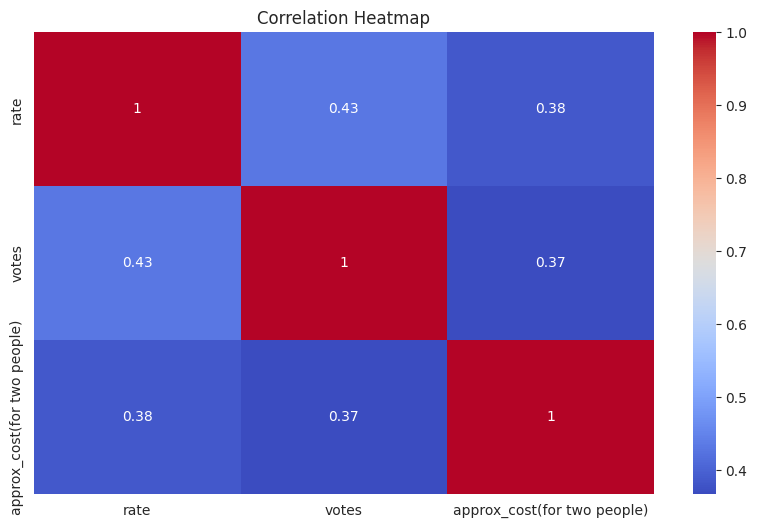

In [16]:
numeric_cols = df.select_dtypes(include=np.number)
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

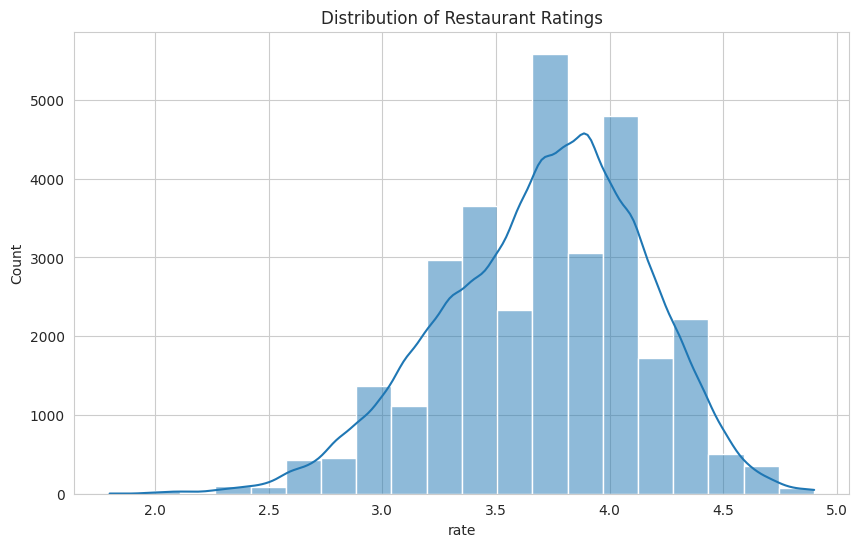

In [10]:
sns.histplot(df['rate'], bins=20, kde=True)
plt.title('Distribution of Restaurant Ratings')
plt.show()

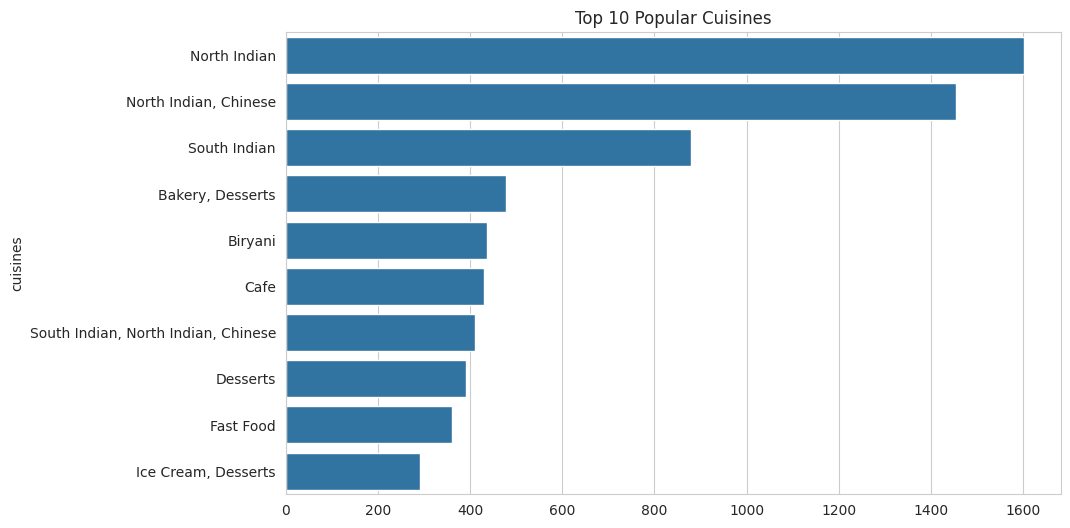

In [11]:
top_cuisines = (
    df['cuisines']
    .value_counts()
    .head(10)
)

sns.barplot(
    x=top_cuisines.values,
    y=top_cuisines.index
)

plt.title('Top 10 Popular Cuisines')
plt.show()

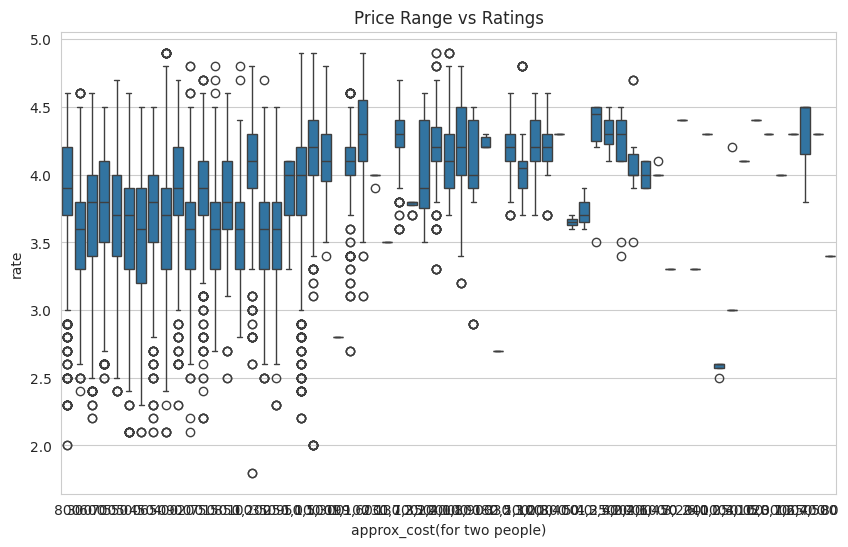

In [12]:
sns.boxplot(
    x='approx_cost(for two people)',
    y='rate',
    data=df
)

plt.title('Price Range vs Ratings')
plt.show()

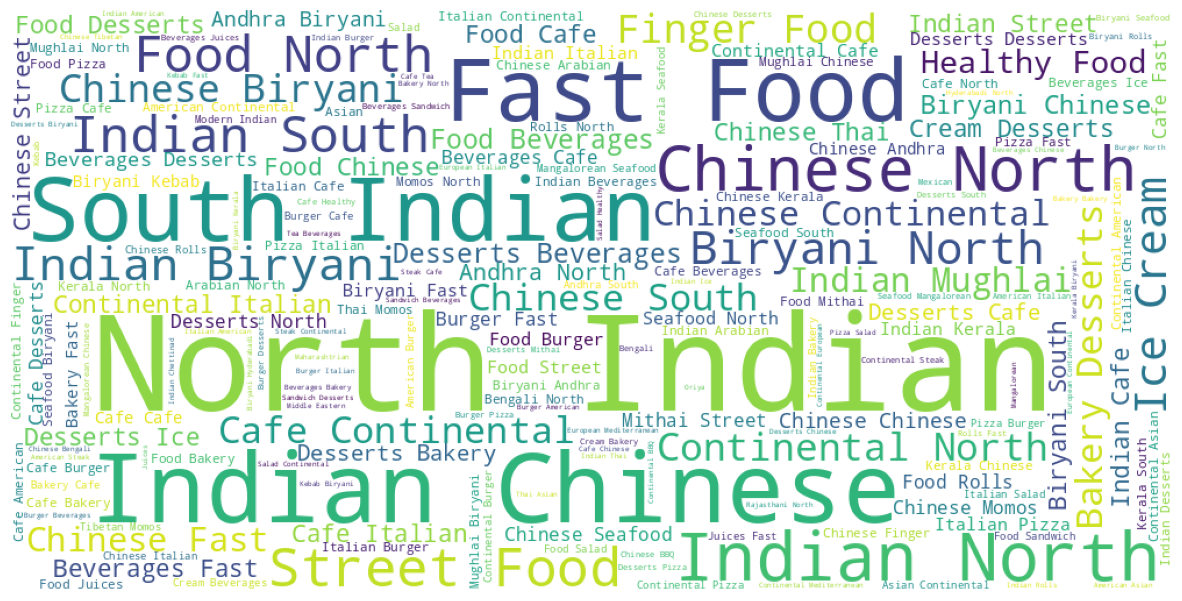

In [17]:
text = " ".join(df['cuisines'].dropna())

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [18]:
cuisine_rating = (
    df.groupby('cuisines')['rate']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(cuisine_rating)

cuisines
Healthy Food, Salad, Mediterranean                                       4.900000
Continental, North Indian, Italian, South Indian, Finger Food            4.900000
Asian, Chinese, Thai, Momos                                              4.900000
Asian, Mediterranean, North Indian, BBQ                                  4.800000
North Indian, European, Mediterranean, BBQ                               4.800000
Continental, North Indian, Chinese, European, BBQ, Finger Food, Asian    4.800000
European, Mediterranean, North Indian, BBQ                               4.764286
American, Tex-Mex, Burger, BBQ, Mexican                                  4.733333
Continental, European, BBQ, Chinese, Asian                               4.700000
Chinese, American, Continental, Italian, North Indian                    4.700000
Name: rate, dtype: float64


In [19]:
df['location'].value_counts().head(15)

,count
location,
BTM,2445
Koramangala 5th Block,1596
Indiranagar,1582
HSR,1562
Whitefield,1482
Marathahalli,1358
JP Nagar,1216
Jayanagar,1189
Bellandur,942


In [20]:
df[['approx_cost(for two people)', 'rate']].corr()

,approx_cost(for two people),rate
approx_cost(for two people),1.000000,0.384962
rate,0.384962,1.000000
